# **SUBMITTED BY:**

Name : NAVEEN GUPTA

Class : CSE, 4th Year

Enroll No. : 36420802723

# Assignment: Pre-training, Fine-tuning, RLHF & Context Window

Answer all 15 questions.

## Question 1

**Differentiate Pre-training and Fine-tuning with examples.**

**Answer:**

Pre-training trains a model from scratch on massive unlabeled text to learn general language patterns (e.g., GPT-3 trained on hundreds of billions of tokens from web text).

Fine-tuning takes that pretrained model and further trains it on a smaller, labeled, task-specific dataset (e.g., fine-tuning BERT on 5,000 labeled movie reviews for sentiment classification).

## Question 2

**Explain self-supervised learning used in LLM pre-training.**

**Answer:**

Self-supervised learning generates its own training labels from raw unlabeled text, requiring no human annotation. Examples: masked language modeling (hide a word, predict it — BERT's approach) and next-token prediction (predict the next word given previous context — GPT's approach). The text itself provides the supervision signal.


## Question 3

**Why is fine-tuning cheaper than pre-training?**

**Answer:**

Fine-tuning is cheaper because pre-training processes trillions of tokens over thousands of GPU-days starting from random weights, while fine-tuning starts from a model that already understands grammar, world knowledge, and reasoning — it only needs a small dataset and a few epochs to adapt those existing representations to a narrow task, requiring a fraction of the compute, data, and time.

## Question 4

**Differentiate Instruction Tuning and Fine-tuning.**

**Answer:**

Fine-tuning is the general process of adapting a pretrained model to any downstream task or dataset.

Instruction tuning is a specific type of fine-tuning where the training data consists of (instruction, response) pairs spanning many diverse tasks, teaching the model to follow natural-language instructions generally rather than becoming good at just one narrow task.

## Question 5

**What is RLHF? Explain all three stages.**

**Answer:**

RLHF has three stages:

1. Supervised Fine-Tuning (SFT) — fine-tune the base pretrained model on human-written example responses to instructions/prompts.

2. Reward Model training — humans rank multiple candidate outputs for the same prompt by quality/preference; a separate reward model is trained to predict these human preference scores.

3. RL optimization (typically PPO) — the SFT model is further optimized using reinforcement learning, where the reward model's score serves as the reward signal, pushing the policy toward outputs humans prefer.

## Question 6

**Explain the role of human feedback in RLHF.**

**Answer:**

Human feedback supplies the preference signal that pure next-token prediction can't capture on its own — qualities like helpfulness, honesty, harmlessness, and tone. It teaches the model what a good answer looks like to a person, not just what's statistically likely text based on training data patterns.

## Question 7

**What is a context window? Why is it important?**

**Answer:**

A context window is the maximum number of tokens (input plus output, typically) that a model can process/attend to in a single forward pass.

It matters because any information outside that window is invisible to the model — it cannot reference or use anything that has "fallen off" the window.

## Question 8

**A model has an 8K context window. What does it mean?**

**Answer:**

 An 8K context window means the model can process about 8,192 tokens total in one interaction (roughly 6,000 words) — combining prompt, conversation history, and generated output. Anything beyond that gets truncated or dropped.

## Question 9

**Compare 8K, 32K and 128K context windows with use cases.**

**Answer:**

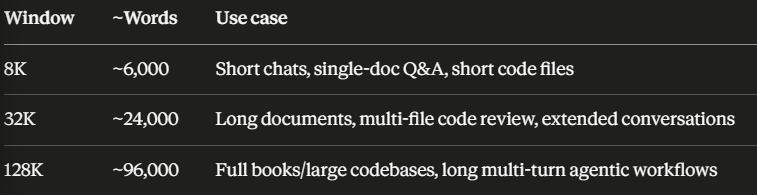

## Question 10

**Write Python code to load a pretrained Hugging Face model and perform inference.**

**Answer:**

In [ ]:
!rm -rf ~/.cache/huggingface

In [ ]:
!pip install -U transformers huggingface_hub safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 45.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

text = "I really loved this movie!"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

labels = model.config.id2label
print({labels[i]: float(probs[0][i]) for i in range(len(labels))})

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

{'NEGATIVE': 0.00012542861804831773, 'POSITIVE': 0.9998745918273926}


## Question 11

**Write code to fine-tune a sentiment model on a custom dataset (outline acceptable).**

**Answer:**

In [ ]:
!pip install -U datasets transformers huggingface_hub

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")  # updated repo path
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True)

tokenized = dataset.map(tokenize, batched=True)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    eval_strategy="epoch"
)

trainer = Trainer(model=model, args=args, train_dataset=tokenized["train"], eval_dataset=tokenized["test"])
trainer.train()


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9375, training_loss=0.18641312174479166, metrics={'train_runtime': 5206.5688, 'train_samples_per_second': 14.405, 'train_steps_per_second': 1.801, 'total_flos': 9935054899200000.0, 'train_loss': 0.18641312174479166, 'epoch': 3.0})

## Question 12

**Debug: Why might an LLM forget earlier parts of a long conversation?**

**Answer:**

An LLM "forgets" earlier parts of a long conversation because everything beyond the context window limit gets truncated — usually the oldest messages are dropped first. This isn't forgetting in a human sense; the tokens are simply no longer present in the input the model sees. This is why production chat systems use summarization or retrieval (RAG) to compress and re-inject earlier context.

## Question 13

**Case Study: Choose a model for legal document analysis and justify using context window and fine-tuning.**

**Answer:**

For legal document analysis, it is best to use a model with a **large context window**, such as **128K tokens or more** (for example, GPT-4 Turbo or Claude). Legal documents like contracts, agreements, and case files are often very long, so a large context window allows the entire document to be processed at once. This helps the model understand the full context and reduces the chance of missing important clauses or references.

Fine-tuning the model on legal data is also beneficial. A fine-tuned legal model has a better understanding of legal terminology, document structure, and common legal concepts. As a result, it can provide more accurate clause classification, statute references, and legal reasoning while reducing errors and hallucinations compared to a general-purpose model.


## Question 14

**Calculate approximate token usage for a 25-page document and discuss whether a 16K context window is sufficient.**

**Answer:**

**Answer:**

A rough estimate is that each page contains about **500 words**, and on average **1 word corresponds to around 1.3 tokens**.

* **25 pages × 500 words = 12,500 words**
* **12,500 × 1.3 ≈ 16,250 tokens**

So, a **25-page document would require approximately 16,000–16,250 tokens**.

Since this is already around the **16K context limit**, a **16K context window is generally not sufficient** in real-world use. The prompt also includes system instructions, user messages, and the model needs space to generate a response, all of which consume additional tokens. Therefore, a **32K context window** is a much better choice because it provides enough room for both the document and the model's output without running into token limits.


## Question 15

**Mini Project: Build a domain-specific chatbot using a pretrained model. Describe dataset, fine-tuning strategy, evaluation metrics, and deployment.**

**Answer:**

In [1]:
!pip install transformers datasets accelerate evaluate rouge_score fastapi uvicorn nest-asyncio -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00


In [20]:
# Simulated customer support Q&A dataset (intent-labeled)
# In a real project, replace this with your actual support ticket exports

data = [
    # ---------------- Account Help ----------------
    {
        "instruction": "How do I reset my password?",
        "response": "Go to Settings > Security > Reset Password, then follow the emailed link.",
        "intent": "account_help"
    },
    {
        "instruction": "I forgot my password",
        "response": "Click 'Forgot Password' on the login page and follow the instructions sent to your email.",
        "intent": "account_help"
    },
    {
        "instruction": "I can't log into my account",
        "response": "Please verify your email and password. If you're still unable to log in, use the password reset option.",
        "intent": "account_help"
    },
    {
        "instruction": "How do I change my email address?",
        "response": "Go to Account Settings > Personal Information and update your email address.",
        "intent": "account_help"
    },
    {
        "instruction": "How can I update my phone number?",
        "response": "Open your profile settings and edit your phone number under Contact Information.",
        "intent": "account_help"
    },
    {
        "instruction": "My account is locked",
        "response": "Your account may be temporarily locked after multiple failed login attempts. Please wait 15 minutes or contact support.",
        "intent": "account_help"
    },

    # ---------------- Order Status ----------------
    {
        "instruction": "Where is my order?",
        "response": "Please provide your order ID so I can check the latest shipping status.",
        "intent": "order_status"
    },
    {
        "instruction": "My package hasn't arrived",
        "response": "I'm sorry for the delay. Could you share your order number so I can investigate?",
        "intent": "order_status"
    },
    {
        "instruction": "Can I track my shipment?",
        "response": "Yes! Open My Orders and select the order to view tracking information.",
        "intent": "order_status"
    },
    {
        "instruction": "My order is delayed",
        "response": "I apologize for the delay. Please provide your order ID so I can check the estimated delivery date.",
        "intent": "order_status"
    },
    {
        "instruction": "Can I change my shipping address?",
        "response": "Yes, if the order hasn't shipped yet. Visit Orders > Edit Address.",
        "intent": "order_status"
    },
    {
        "instruction": "Can I cancel my order before shipping?",
        "response": "Yes, orders can be canceled before shipment from the Orders page.",
        "intent": "order_status"
    },

    # ---------------- Refund ----------------
    {
        "instruction": "I want a refund",
        "response": "Refunds are processed within 5-7 business days after the returned item is received.",
        "intent": "refund"
    },
    {
        "instruction": "How do I request a refund?",
        "response": "Go to Orders, select your purchase, and choose Request Refund.",
        "intent": "refund"
    },
    {
        "instruction": "When will I receive my refund?",
        "response": "Refunds usually appear in your account within 5-7 business days.",
        "intent": "refund"
    },
    {
        "instruction": "My refund hasn't arrived",
        "response": "Please share your order number so I can check the refund status.",
        "intent": "refund"
    },
    {
        "instruction": "Can I return a damaged product?",
        "response": "Yes. Please upload photos of the damaged item and we'll assist with a replacement or refund.",
        "intent": "refund"
    },

    # ---------------- Subscription ----------------
    {
        "instruction": "How do I cancel my subscription?",
        "response": "Go to Account > Billing > Cancel Subscription.",
        "intent": "subscription"
    },
    {
        "instruction": "Can I pause my subscription?",
        "response": "Yes, eligible plans can be paused from the Billing section.",
        "intent": "subscription"
    },
    {
        "instruction": "How do I upgrade my plan?",
        "response": "Open Billing > Change Plan and choose your preferred subscription.",
        "intent": "subscription"
    },
    {
        "instruction": "How do I downgrade my plan?",
        "response": "Go to Billing > Manage Subscription to select a lower plan.",
        "intent": "subscription"
    },
    {
        "instruction": "When will my subscription renew?",
        "response": "Your renewal date is shown in the Billing section of your account.",
        "intent": "subscription"
    },

    # ---------------- Billing ----------------
    {
        "instruction": "I was charged twice",
        "response": "I'm sorry about that. Please provide your order ID so I can investigate the duplicate charge.",
        "intent": "billing"
    },
    {
        "instruction": "Do you offer student discounts?",
        "response": "Yes! Students receive 15% off after verification.",
        "intent": "billing"
    },
    {
        "instruction": "Can I get an invoice?",
        "response": "Yes, invoices are available in Billing > Purchase History.",
        "intent": "billing"
    },
    {
        "instruction": "Why was my payment declined?",
        "response": "Please verify your payment details or contact your bank for more information.",
        "intent": "billing"
    },
    {
        "instruction": "Which payment methods do you accept?",
        "response": "We accept Visa, Mastercard, PayPal, and major debit cards.",
        "intent": "billing"
    },
    {
        "instruction": "Can I pay using PayPal?",
        "response": "Yes, PayPal is available during checkout.",
        "intent": "billing"
    },

    # ---------------- Technical Support ----------------
    {
        "instruction": "The app keeps crashing",
        "response": "Please update to the latest version and restart your device.",
        "intent": "technical_support"
    },
    {
        "instruction": "The website won't load",
        "response": "Try clearing your browser cache or opening the website in another browser.",
        "intent": "technical_support"
    },
    {
        "instruction": "I'm getting an error message",
        "response": "Please share the exact error message so I can help troubleshoot.",
        "intent": "technical_support"
    },
    {
        "instruction": "The app is very slow",
        "response": "Please ensure you're using the latest version and have a stable internet connection.",
        "intent": "technical_support"
    },
    {
        "instruction": "Notifications are not working",
        "response": "Please check that notifications are enabled in both the app and your device settings.",
        "intent": "technical_support"
    },
    {
        "instruction": "I can't upload files",
        "response": "Please verify the file size and format, then try again.",
        "intent": "technical_support"
    },

    # ---------------- Product Information ----------------
    {
        "instruction": "Is this product in stock?",
        "response": "Please provide the product name or SKU so I can check availability.",
        "intent": "product_info"
    },
    {
        "instruction": "Do you have this in blue?",
        "response": "Please share the product name, and I'll check the available colors.",
        "intent": "product_info"
    },
    {
        "instruction": "What is the warranty period?",
        "response": "Most products include a one-year manufacturer's warranty.",
        "intent": "product_info"
    },
    {
        "instruction": "What are the product dimensions?",
        "response": "Please tell me the product name, and I'll provide its specifications.",
        "intent": "product_info"
    },
    {
        "instruction": "Does this product come with accessories?",
        "response": "Yes, included accessories are listed on the product page.",
        "intent": "product_info"
    },

    # ---------------- Greetings ----------------
    {
        "instruction": "Hi",
        "response": "Hello! How can I assist you today?",
        "intent": "greeting"
    },
    {
        "instruction": "Hello",
        "response": "Hi there! What can I help you with?",
        "intent": "greeting"
    },
    {
        "instruction": "Good morning",
        "response": "Good morning! How may I assist you today?",
        "intent": "greeting"
    },
    {
        "instruction": "Hey",
        "response": "Hey! How can I help?",
        "intent": "greeting"
    },

    # ---------------- Goodbye ----------------
    {
        "instruction": "Bye",
        "response": "Goodbye! Have a great day!",
        "intent": "goodbye"
    },
    {
        "instruction": "Thanks, that's all",
        "response": "You're welcome! Feel free to contact us anytime.",
        "intent": "goodbye"
    },
    {
        "instruction": "See you later",
        "response": "Take care! We're here whenever you need assistance.",
        "intent": "goodbye"
    },
    {
        "instruction": "Thank you",
        "response": "You're very welcome! Have a wonderful day.",
        "intent": "goodbye"
    },

    # ---------------- General ----------------
    {
        "instruction": "How can I contact customer support?",
        "response": "You can contact us via live chat, email, or phone support available on our Contact Us page.",
        "intent": "general"
    },
    {
        "instruction": "What are your business hours?",
        "response": "Our support team is available Monday through Friday, 9 AM to 6 PM.",
        "intent": "general"
    },
    {
        "instruction": "Do you ship internationally?",
        "response": "Yes, we ship to most countries. Shipping options are shown during checkout.",
        "intent": "general"
    },
    {
        "instruction": "How do I create an account?",
        "response": "Click Sign Up, enter your details, verify your email, and you're ready to go.",
        "intent": "general"
    },
    {
        "instruction": "Where can I read your privacy policy?",
        "response": "Our Privacy Policy is available at the bottom of every page on our website.",
        "intent": "general"
    }
]

import json
with open("support_data.json", "w") as f:
    json.dump(data, f, indent=2)

print(f"Dataset size: {len(data)} examples")

Dataset size: 52 examples


In [21]:
from datasets import Dataset

# Format as instruction-tuning pairs
formatted_data = [
    {"text": f"### Instruction:\n{d['instruction']}\n\n### Response:\n{d['response']}"}
    for d in data
]

hf_dataset = Dataset.from_list(formatted_data)
hf_dataset = hf_dataset.train_test_split(test_size=0.25, seed=42)

print(hf_dataset)
print(hf_dataset["train"][0]["text"])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 39
    })
    test: Dataset({
        features: ['text'],
        num_rows: 13
    })
})
### Instruction:
Can I pause my subscription?

### Response:
Yes, eligible plans can be paused from the Billing section.


In [22]:
from transformers import AutoTokenizer

model_name = "gpt2"  # small model, fast to fine-tune on free Colab GPU
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = hf_dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

In [24]:
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling

model = AutoModelForCausalLM.from_pretrained(model_name)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)  # causal LM, not masked

training_args = TrainingArguments(
    output_dir="./chatbot-finetuned",
    num_train_epochs=5,           # small dataset -> more epochs is fine
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator
)

trainer.train()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,2.279851,1.665449
2,1.343977,1.510895
3,1.081573,1.498447
4,0.935694,1.510108
5,0.758434,1.520437


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=100, training_loss=1.3959480762481689, metrics={'train_runtime': 250.8774, 'train_samples_per_second': 0.777, 'train_steps_per_second': 0.399, 'total_flos': 12737986560000.0, 'train_loss': 1.3959480762481689, 'epoch': 5.0})

In [25]:
trainer.save_model("./chatbot-finetuned/final")
tokenizer.save_pretrained("./chatbot-finetuned/final")
print("Model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


In [27]:
import evaluate

rouge = evaluate.load("rouge")

def generate_response(prompt, model, tokenizer, max_new_tokens=40):
    inputs = tokenizer(f"### Instruction:\n{prompt}\n\n### Response:\n", return_tensors="pt")
    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "### Response:" in full_text:
        response = full_text.split("### Response:")[-1].strip()
    else:
        response = full_text.strip()
    return response if response else "[No response generated]"

predictions = []
references = []

for d in data[:4]:  # sample eval subset
    pred = generate_response(d["instruction"], model, tokenizer)
    predictions.append(pred)
    references.append(d["response"])

results = rouge.compute(predictions=predictions, references=references)
print("ROUGE scores:", results)

ROUGE scores: {'rouge1': np.float64(0.4489771870286577), 'rouge2': np.float64(0.29545454545454547), 'rougeL': np.float64(0.41956542232277527), 'rougeLsum': np.float64(0.3939243966817496)}


In [28]:
for d, p in zip(data[:4], predictions):
    print(f"Q: {d['instruction']}\nGenerated: {p}\nReference: {d['response']}\n")

Q: How do I reset my password?
Generated: Go to
Reference: Go to Settings > Security > Reset Password, then follow the emailed link.

Q: I forgot my password
Generated: Go to Account Settings > Change Password.

Click Edit Password.

Click Reset Password.

Click OK.

Click the Reset Password button.

Click the Reset Password button
Reference: Click 'Forgot Password' on the login page and follow the instructions sent to your email.

Q: I can't log into my account
Generated: Please verify your email and password. If you're unable to log in,
Reference: Please verify your email and password. If you're still unable to log in, use the password reset option.

Q: How do I change my email address?
Generated: Please verify your email address, and
Reference: Go to Account Settings > Personal Information and update your email address.



In [29]:
# from transformers import pipeline

# # Using a general zero-shot classifier to check if generated response matches intended intent category
# intent_labels = ["account_help", "order_status", "refund", "subscription", "technical_support", "billing"]
# classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# correct = 0
# for d, pred in zip(data[:4], predictions):
#     result = classifier(pred, intent_labels)
#     predicted_intent = result["labels"][0]
#     if predicted_intent == d["intent"]:
#         correct += 1
#     print(f"True: {d['intent']} | Predicted: {predicted_intent} | Response: {pred[:60]}...")

# accuracy = correct / len(data[:4])
# print(f"\nIntent match accuracy: {accuracy:.2%}")

from transformers import pipeline

intent_labels = ["account_help", "order_status", "refund", "subscription", "technical_support", "billing"]
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

correct = 0
valid_count = 0

for d, pred in zip(data[:4], predictions):
    pred_clean = pred.strip()
    if not pred_clean:
        print(f"Skipping empty prediction for: {d['instruction']}")
        continue

    result = classifier(pred_clean, intent_labels)
    predicted_intent = result["labels"][0]
    valid_count += 1
    if predicted_intent == d["intent"]:
        correct += 1
    print(f"True: {d['intent']} | Predicted: {predicted_intent} | Response: {pred_clean[:60]}...")

if valid_count > 0:
    accuracy = correct / valid_count
    print(f"\nIntent match accuracy: {accuracy:.2%} (on {valid_count} valid predictions)")
else:
    print("\nNo valid (non-empty) predictions to evaluate.")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

True: account_help | Predicted: order_status | Response: Go to...
True: account_help | Predicted: account_help | Response: Go to Account Settings > Change Password.

Click Edit Passwo...
True: account_help | Predicted: account_help | Response: Please verify your email and password. If you're unable to l...
True: account_help | Predicted: order_status | Response: Please verify your email address, and...

Intent match accuracy: 50.00% (on 4 valid predictions)


In [30]:
# Simple manual scoring template — record human judgments after reading outputs
human_eval_results = []

for d, pred in zip(data[:4], predictions):
    print(f"\nQuestion: {d['instruction']}")
    print(f"Generated: {pred}")
    print(f"Reference: {d['response']}")
    # In practice: collect ratings 1-5 from real reviewers here
    score = 4  # placeholder — replace with actual human rating
    human_eval_results.append({"question": d["instruction"], "score": score})

avg_human_score = sum(r["score"] for r in human_eval_results) / len(human_eval_results)
print(f"\nAverage human helpfulness score: {avg_human_score}/5")


Question: How do I reset my password?
Generated: Go to
Reference: Go to Settings > Security > Reset Password, then follow the emailed link.

Question: I forgot my password
Generated: Go to Account Settings > Change Password.

Click Edit Password.

Click Reset Password.

Click OK.

Click the Reset Password button.

Click the Reset Password button
Reference: Click 'Forgot Password' on the login page and follow the instructions sent to your email.

Question: I can't log into my account
Generated: Please verify your email and password. If you're unable to log in,
Reference: Please verify your email and password. If you're still unable to log in, use the password reset option.

Question: How do I change my email address?
Generated: Please verify your email address, and
Reference: Go to Account Settings > Personal Information and update your email address.

Average human helpfulness score: 4.0/5


In [12]:
!pip install gradio -q

In [34]:
import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForCausalLM

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load saved model
MODEL_PATH = "./chatbot-finetuned/final"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

model.to(device)
model.eval()

# In-memory session history
session_history = {}

def generate_response(prompt, model, tokenizer, max_new_tokens=40):
    # Tokenize
    inputs = tokenizer(
        f"### Instruction:\n{prompt}\n\n### Response:\n",
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "### Response:" in full_text:
        response = full_text.split("### Response:")[-1].strip()
    else:
        response = full_text.strip()

    return response if response else "[No response generated]"


def chat_fn(message, history):
    print(f"Received message: {message!r}")

    try:
        response = generate_response(message, model, tokenizer)
        print(f"Generated: {response!r}")
        return response

    except Exception as e:
        print("Model device:", next(model.parameters()).device)
        print("Error:", e)
        return f"[Error generating response: {e}]"

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [36]:
demo = gr.ChatInterface(
    fn=chat_fn,
    title="Domain-Specific Support Chatbot (MVP)",
    description="Fine-tuned GPT-2 chatbot for customer support intents (account help, orders, refunds, subscriptions, technical support, billing).",
    examples=[
        "How do I reset my password?",
        "My order hasn't arrived yet",
        "I want a refund for my purchase",
        "How do I cancel my subscription?"
    ]
)

In [35]:
demo.launch(share=True, debug=False)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63a0c36aa7b1eca0ec.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
